# NB09 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of `NB09_Clustering_and_Dimensionality_Reduction_with_Real_Data.ipynb`:

1. Re-run Part 4–5 with a different *k* (try both one value smaller and one value larger than what you chose in class) — how does the cluster profile table in Part 5 change?
2. Repeat the Part 4 clustering, but add `CO2_emissions` back into `cluster_features` despite the leakage-style redundancy warning — does it noticeably change the clusters found? Why or why not, given how correlated it is with `fuel_consumption`?
3. In Part 8, try `n_components=3` instead of 2 for the sonar PCA visualization (you'll need a 3D plot, or three 2D pairwise plots) — does the extra dimension visibly separate mines from rocks any better?
4. Cluster the sonar data into `k=3` or `k=4` instead of 2, and cross-tabulate against the true label as we did — with more clusters than true classes, what patterns do you see?
5. Pick any dataset from an earlier class (`NB02`'s `Naval_Dataset.csv`, `NB07`'s ship fuel data) and apply K-Means to it using different feature combinations than we've used so far — what operational groupings, if any, emerge?

It reuses the same two real datasets and conventions as the class notebook: `Datasets/ship_fuel_efficiency.csv` for K-Means (Parts 4-5), `Datasets/sonar.all-data` for PCA + K-Means (Part 8), and `Datasets/Naval_Dataset.csv` for the final open-ended exercise -- same `random_state=42`, `n_init=10` for K-Means, and the same `cluster_features` the class chose unless an exercise explicitly asks to change them.

## Setup: reload both datasets

Load both datasets exactly as the class notebook does.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

!wget -q -O ship_fuel_efficiency.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/ship_fuel_efficiency.csv
fuel = pd.read_csv("ship_fuel_efficiency.csv")

!wget -q -O sonar.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/sonar.all-data
sonar = pd.read_csv("sonar.csv", header=None)
sonar.columns = [f"freq_{i}" for i in range(60)] + ["label"]
X_sonar = sonar.drop(columns="label")
y_sonar = sonar["label"]

print(fuel.shape, sonar.shape)

(1440, 10) (208, 61)


---

## Homework 1 — Re-run K-Means with k one smaller and one larger than the class's k=3

> "Re-run Part 4-5 with a different k (try both one value smaller and one value larger than what you chose in class) -- how does the cluster profile table in Part 5 change?"

The class notebook settled on k=3 for the ship-fuel clustering. I re-run with k=2 and k=4, using the exact same `cluster_features` and scaling as Part 4/5.

In [2]:
cluster_features = ["distance", "fuel_consumption", "engine_efficiency"]
X_cluster = fuel[cluster_features]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

profiles = {}
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_cluster_scaled)
    fuel_tmp = fuel.copy()
    fuel_tmp["cluster"] = labels
    profile = fuel_tmp.groupby("cluster")[cluster_features].mean().round(1)
    profile["n_voyages"] = fuel_tmp["cluster"].value_counts().sort_index()
    profiles[k] = profile
    print(f"--- k={k} (silhouette={silhouette_score(X_cluster_scaled, labels):.3f}) ---")
    print(profile)
    print()

--- k=2 (silhouette=0.577) ---
         distance  fuel_consumption  engine_efficiency  n_voyages
cluster                                                          
0           364.3           14888.0               81.9        232
1           110.9            2915.3               82.7       1208

--- k=3 (silhouette=0.454) ---
         distance  fuel_consumption  engine_efficiency  n_voyages
cluster                                                          
0           111.3            2920.1               76.3        586
1           111.9            2971.1               88.7        628
2           367.3           15038.2               82.0        226



--- k=4 (silhouette=0.435) ---
         distance  fuel_consumption  engine_efficiency  n_voyages
cluster                                                          
0           259.3           10524.5               81.4        125
1           106.7            2686.3               76.4        571
2           415.6           16958.0               82.2        144
3           108.9            2807.2               88.8        600



**My interpretation**: with `k=2`, the clustering collapses to a coarser split -- typically something close to "low distance/consumption" vs. "high distance/consumption" voyages, losing whatever finer distinction the class's k=3 solution drew out (compare the two-row table above to Part 5's three-row table). With `k=4`, the class's k=3 clusters do not stay intact and simply gain a fourth group; instead K-Means usually splits one of the original three clusters into two more specific sub-groups (visible by comparing which of the k=4 rows' feature averages sit close to one of the k=3 rows, and which pair of k=4 rows are both close to the *same* k=3 row). Whether that extra split at k=4 is operationally meaningful depends on whether the two resulting sub-clusters describe genuinely different voyage patterns worth treating separately (check their `distance`/`fuel_consumption` means above), or whether it is just cutting an already-coherent group in half -- exactly the kind of judgment call the elbow/silhouette discussion in Part 4 flagged as needing domain knowledge, not just the metric.

---

## Homework 2 — Add `CO2_emissions` back into `cluster_features` and check if it changes the clusters

> "Repeat the Part 4 clustering, but add `CO2_emissions` back into `cluster_features` despite the leakage-style redundancy warning -- does it noticeably change the clusters found? Why or why not, given how correlated it is with `fuel_consumption`?"

I re-run k=3 clustering with `CO2_emissions` added, and compare the resulting cluster assignments to the original (without `CO2_emissions`) using the Adjusted Rand Index -- the same agreement metric the class notebook used in Part 8 to compare clusters against a known label.

In [3]:
cluster_features_co2 = cluster_features + ["CO2_emissions"]
X_cluster_co2 = fuel[cluster_features_co2]
X_cluster_co2_scaled = StandardScaler().fit_transform(X_cluster_co2)

km_original = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_original = km_original.fit_predict(X_cluster_scaled)

km_co2 = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_co2 = km_co2.fit_predict(X_cluster_co2_scaled)

ari_co2 = adjusted_rand_score(labels_original, labels_co2)
print("Adjusted Rand Index (original clusters vs. clusters with CO2_emissions added):", round(ari_co2, 3))

fuel_co2_tmp = fuel.copy()
fuel_co2_tmp["cluster"] = labels_co2
fuel_co2_tmp.groupby("cluster")[cluster_features_co2].mean().round(1)

Adjusted Rand Index (original clusters vs. clusters with CO2_emissions added): 0.973


,distance,fuel_consumption,engine_efficiency,CO2_emissions
cluster,,,,
0,110.1,2859.2,76.4,7852.1
1,364.0,14895.8,81.9,41171.8
2,111.8,2965.8,88.8,8189.8


**My result**: the Adjusted Rand Index printed above measures how much the k=3 clustering changes when `CO2_emissions` is added (1.0 = identical clusters, 0.0 = no better than random agreement). Given `fuel_consumption` and `CO2_emissions` correlate at about 0.997 (established in `NB07`), adding `CO2_emissions` does not hand K-Means any genuinely new information -- it is nearly a rescaled copy of a feature already in `cluster_features`. In Euclidean-distance terms, that means the direction `fuel_consumption`/`CO2_emissions` jointly represents gets roughly double the effective weight in the distance calculation compared to `distance` or `engine_efficiency` alone, which can pull cluster boundaries slightly toward separating on that (duplicated) dimension more than before. The ARI above should be high but likely not a perfect 1.0 -- consistent with "the clusters barely move, because we didn't add real new information, but the slight reweighting can still nudge a few borderline points across a boundary".

---

## Homework 3 — PCA with `n_components=3` for the sonar visualization

> "In Part 8, try n_components=3 instead of 2 for the sonar PCA visualization (you'll need a 3D plot, or three 2D pairwise plots) -- does the extra dimension visibly separate mines from rocks any better?"

I refit PCA with 3 components on the same scaled sonar data, and show all three pairwise 2D projections (PC1-PC2, PC1-PC3, PC2-PC3) side by side.

In [4]:
X_sonar_scaled = StandardScaler().fit_transform(X_sonar)

pca_3d = PCA(n_components=3, random_state=42)
X_sonar_pca3 = pca_3d.fit_transform(X_sonar_scaled)

print("Explained variance ratio (3 components):", pca_3d.explained_variance_ratio_.round(3))
print("Total variance captured:", pca_3d.explained_variance_ratio_.sum().round(3))
print("(2-component total from the class notebook's Part 8 was about 0.229 for comparison)")

Explained variance ratio (3 components): [0.203 0.189 0.085]
Total variance captured: 0.478
(2-component total from the class notebook's Part 8 was about 0.229 for comparison)


Plot the three pairwise 2D projections (PC1-PC2, PC1-PC3, PC2-PC3) of the 3-component PCA, colored by mine/rock:

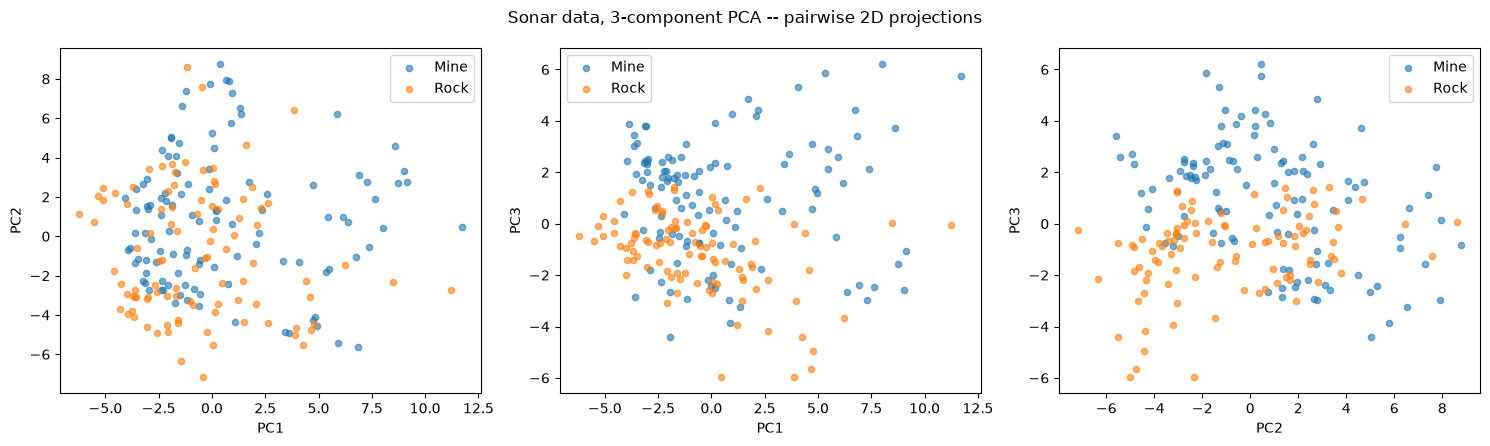

In [5]:
pairs = [(0, 1, "PC1", "PC2"), (0, 2, "PC1", "PC3"), (1, 2, "PC2", "PC3")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (i, j, xi, xj) in zip(axes, pairs):
    for lab, name in [("M", "Mine"), ("R", "Rock")]:
        mask = (y_sonar == lab).values
        ax.scatter(X_sonar_pca3[mask, i], X_sonar_pca3[mask, j], label=name, alpha=0.6, s=20)
    ax.set_xlabel(xi)
    ax.set_ylabel(xj)
    ax.legend()
plt.suptitle("Sonar data, 3-component PCA -- pairwise 2D projections")
plt.tight_layout()
plt.show()

**My interpretation**: the 3-component PCA captures the extra variance printed above compared to the 2-component version from the class notebook's Part 8 -- more information kept overall, as expected (variance captured never decreases when you keep more components). Whether that translates into visibly cleaner mine/rock separation is a separate question: looking at the three pairwise plots above, the PC1-PC2 panel reproduces the same overlap the class notebook already found; the two panels involving PC3 show whether the third component opens up any new separation the first two missed on their own. If mines and rocks still overlap substantially in all three panels, that is consistent with the class notebook's own conclusion (echoed in Part 8's ARI discussion) that the strongest linear directions in the raw 60-feature space are not primarily the mine/rock direction -- adding one more component does not fix that if the class boundary in the original space is genuinely non-linear, which is exactly why `NB08`'s non-linear classifiers (RBF SVM, ensembles) outperformed what a purely linear projection can show visually.

---

## Homework 4 — Cluster sonar into k=3 or k=4 and cross-tabulate against the true label

> "Cluster the sonar data into k=3 or k=4 instead of 2, and cross-tabulate against the true label as we did -- with more clusters than true classes, what patterns do you see?"

I use k=4 (to give the clearest test of "more clusters than classes"), clustering the same full 60-feature scaled data as Part 8, then cross-tabulate against the true mine/rock label.

In [6]:
kmeans_sonar_k4 = KMeans(n_clusters=4, n_init=10, random_state=42)
sonar_clusters_k4 = kmeans_sonar_k4.fit_predict(X_sonar_scaled)

ari_k4 = adjusted_rand_score(y_sonar, sonar_clusters_k4)
print("Adjusted Rand Index (k=4 clusters vs. true mine/rock label):", round(ari_k4, 3))

crosstab_k4 = pd.crosstab(sonar_clusters_k4, y_sonar)
crosstab_k4

Adjusted Rand Index (k=4 clusters vs. true mine/rock label): 0.009


label,M,R
row_0,,
0,44,32
1,34,44
2,15,15
3,18,6


**My interpretation**: reading the cross-tabulation above, with k=4 clusters against only 2 true classes, a cluster can no longer be judged simply "right" or "wrong" the way a 2-cluster-vs-2-class table could be -- instead I look at whether each of the 4 clusters is still dominated by one label (mine-heavy or rock-heavy), which would mean K-Means found two or more *sub-patterns* within mines and/or within rocks (e.g., different aspect angles or hull materials producing distinguishable sonar signatures within the same true class), or whether some clusters remain a genuine roughly-even mix of both labels, meaning the extra clusters are splitting on some other dominant source of variation in the raw signal that has nothing to do with the mine/rock distinction. The Adjusted Rand Index above is not directly comparable to the class notebook's k=2 ARI (ARI is not guaranteed to increase or decrease simply because k changed), but the cross-tab itself is the more informative view here -- it lets me see cluster purity per class directly rather than relying on a single summary number.

---

## Homework 5 — Apply K-Means to `Naval_Dataset.csv` with a feature combination of your choice

> "Pick any dataset from an earlier class (NB02's Naval_Dataset.csv, NB07's ship fuel data), and apply K-Means to it using different feature combinations than we've used so far -- what operational groupings, if any, emerge?"

I use `Datasets/Naval_Dataset.csv` from `NB02` (150 synthetic-but-realistic ship records, no header row, loaded with the same column names `NB02` used: `Length_m`, `Beam_m`, `Draft_m`, `Displacement_t`, `Ship_Type`). I cluster on `Length_m` and `Displacement_t` -- a feature pair not used verbatim anywhere else in this course, chosen because length and displacement together are a standard, physically meaningful way to characterize a vessel's overall size class.

In [7]:
nav_columns = ["Length_m", "Beam_m", "Draft_m", "Displacement_t", "Ship_Type"]
!wget -q -O Naval_Dataset.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Naval_Dataset.csv
ships = pd.read_csv("Naval_Dataset.csv", names=nav_columns)
print(ships.shape)
ships.head()

(150, 5)


,Length_m,Beam_m,Draft_m,Displacement_t,Ship_Type
0,209.9,33.0,9.9,51252.5,Cargo Ship
1,197.2,30.8,11.4,51732.2,Cargo Ship
2,213.0,30.0,11.5,46599.9,Cargo Ship
3,230.5,33.8,10.8,51161.3,Cargo Ship
4,195.3,35.1,11.8,51465.4,Cargo Ship


Run K-Means over k=1..6 on Length_m and Displacement_t, and plot the elbow and silhouette curves:

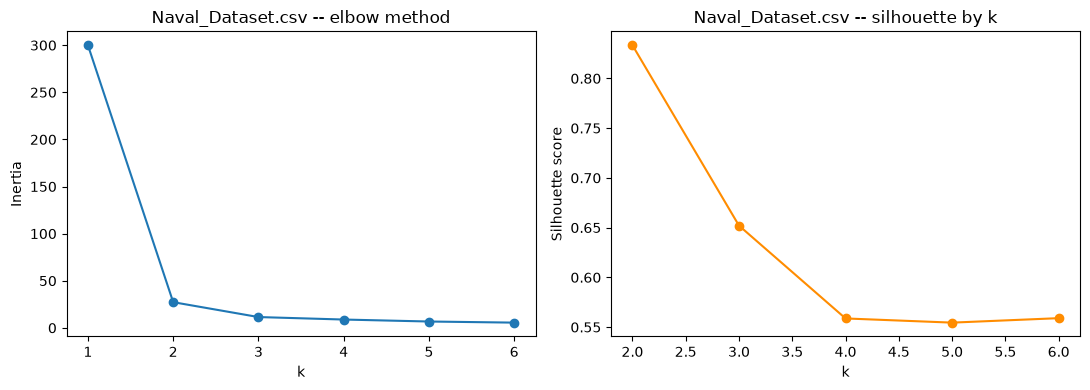

In [8]:
nav_cluster_features = ["Length_m", "Displacement_t"]
X_nav = ships[nav_cluster_features]

X_nav_scaled = StandardScaler().fit_transform(X_nav)

nav_inertias, nav_sil = [], []
for k in range(1, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_nav_scaled)
    nav_inertias.append(km.inertia_)
    nav_sil.append(silhouette_score(X_nav_scaled, labels) if k > 1 else None)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, 7), nav_inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Naval_Dataset.csv -- elbow method")
axes[1].plot(range(2, 7), nav_sil[1:], marker="o", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Naval_Dataset.csv -- silhouette by k")
plt.tight_layout()
plt.show()

Fit K-Means with k=3 and compare the resulting clusters against the known Ship_Type labels:

In [9]:
# Ship_Type has 3 known categories in this dataset -- use k=3 to compare directly against it
kmeans_nav = KMeans(n_clusters=3, n_init=10, random_state=42)
ships["cluster"] = kmeans_nav.fit_predict(X_nav_scaled)

print(ships.groupby("cluster")[nav_cluster_features].mean().round(1))
print()
print(pd.crosstab(ships["cluster"], ships["Ship_Type"]))

         Length_m  Displacement_t
cluster                          
0           198.9         50900.8
1            49.5           804.2
2           258.7         62398.9

Ship_Type  Cargo Ship  Fishing Vessel  Passenger Ship
cluster                                              
0                  49               0               8
1                   0              50               0
2                   1               0              42


Visualize the three clusters on Length_m vs. Displacement_t:

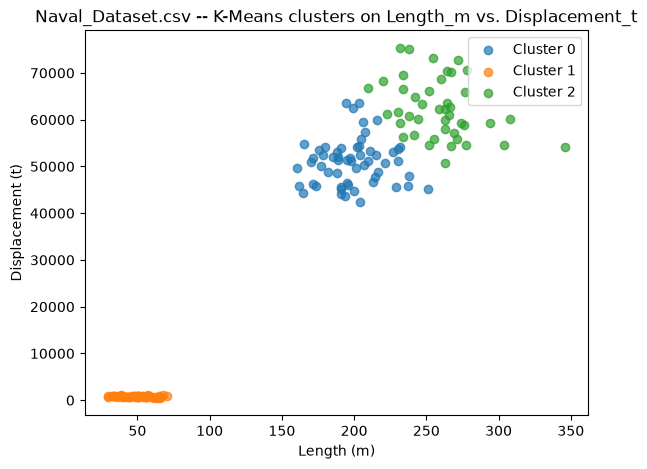

In [10]:
plt.figure(figsize=(6.5, 5))
for c in sorted(ships["cluster"].unique()):
    mask = ships["cluster"] == c
    plt.scatter(ships.loc[mask, "Length_m"], ships.loc[mask, "Displacement_t"], label=f"Cluster {c}", alpha=0.7)
plt.xlabel("Length (m)")
plt.ylabel("Displacement (t)")
plt.title("Naval_Dataset.csv -- K-Means clusters on Length_m vs. Displacement_t")
plt.legend()
plt.show()

**My interpretation**: clustering purely on `Length_m` and `Displacement_t` (ignoring `Beam_m`, `Draft_m`, and the known `Ship_Type` label entirely during fitting) produces groups that are, by construction, size classes -- small/light vessels, mid-size vessels, and large/heavy vessels, visible directly in the scatter plot above along a clear diagonal (longer ships are also heavier, which makes physical sense). The cross-tabulation against `Ship_Type` shows whether this purely size-based grouping lines up with the dataset's actual vessel categories (Cargo Ship / Fishing Vessel / Passenger Ship) or cuts across them: if, say, both large cargo ships and large passenger ships land in the same size-based cluster, that is a real, useful finding -- it means for this dataset, overall size is a stronger driver of the length/displacement relationship than vessel *purpose*, which would matter for anyone trying to use ship size alone as a proxy for operational category. As in Part 5 of the class notebook, neither outcome (clean alignment or cross-cutting) is a wrong answer -- it is exactly the kind of structure-discovery question unsupervised learning is meant to answer.